## week 7 data visualization homework

digma, ronachel marie of h3101

### imports and load finalized datasets

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# load datasets
customers = pd.read_csv(
    "../data/processed/customer_demographics_preprocessed.csv"
)

transactions = pd.read_csv(
    "../data/processed/customer_transactions_preprocessed.csv"
)

social_media = pd.read_csv(
    "../data/processed/social_media_interactions_preprocessed.csv"
)

### inspect

In [8]:
print("Customer Demographics:", customers.shape)
print("Transactions:", transactions.shape)
print("Social Media:", social_media.shape)

# display first few rows of the datasets
display(customers.head())
display(transactions.head())
display(social_media.head())

Customer Demographics: (3000, 6)
Transactions: (3015, 6)
Social Media: (3020, 6)


,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate
0,0009fdd2-ae63-45ca-8d5b-d0ea98381f7b,21.0,Female,Lake George,Low,2020-11-09
1,000c6bbd-533a-432d-922c-ab64197e71c5,25.0,Male,North Oliviaton,High,2019-11-06
2,00115fc0-f155-42cd-ba68-58aab67b3360,36.0,Male,Nelsonstad,Low,2022-02-16
3,00145374-004a-4685-af4d-c8a8967b969e,69.0,Female,Jacquelinehaven,Unknown,2023-04-28
4,0047d8ce-a5bb-4db7-860f-6ff66e1cd060,40.0,Male,Mitchellview,Medium,2021-11-11


,CustomerID,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod
0,60567026-f719-4cd6-849e-137e86d8938f,5ff75116-0a50-4d04-80fb-31e5ccbb0769,2024-05-15,117.64,Clothing,PayPal
1,4090ba85-b111-4f75-a792-c777965f5255,2c39b9fe-ff57-4d39-9321-9f5cdf187aa1,2023-04-26,466.14,Health & Beauty,Bank Transfer
2,9223891b-73ff-4d5c-b8ae-13ece82ee28b,f79588dd-3db9-4ffa-97f8-7de0e64259f1,2022-09-23,563.99,Clothing,Debit Card
3,9243eebc-938f-480c-8564-16d503d250de,401c0fc9-60df-4455-ad78-67c132f9897d,2024-04-15,254.44,Automotive,PayPal
4,6e3e8eb8-bc0f-4ffe-9f74-5d5efec9502f,2034aebc-8280-4254-a667-92bcd1c2be4f,2024-06-03,590.52,Home & Garden,Bank Transfer


,CustomerID,InteractionID,InteractionDate,Platform,InteractionType,Sentiment
0,2dcb9523-356b-40b2-a67b-1f27797de261,e5d15761-d0a7-4329-89e3-79a892c56097,2023-07-11,Unknown,Comment,Unknown
1,e12c37b3-7d4d-472f-9fd8-0df2cb3001aa,02f9f376-70ae-4fcd-9070-1db977939948,2023-07-06,Twitter,Share,Unknown
2,08a911a3-65e6-4f5d-a6a1-ae7ddcbe28a2,a83fa04c-f109-4f24-8ce1-2078154f6a1c,2024-05-24,Instagram,Comment,Neutral
3,efdfdfc9-5dbb-4478-911a-101a390a0285,28a69c4b-a2e4-4c74-a130-1132d7733fdf,2023-11-01,Instagram,Like,Neutral
4,ca1e90f6-0e5f-492e-ab92-252ff540da18,d9d1c6f8-5e15-4738-b52b-13c2982420cc,2023-07-08,Instagram,Like,Unknown


### data verification

In [10]:
print("Customer-level observations:", len(customers))
print("Transaction-level observations:", len(transactions))
print("Social-media interaction-level observations:", len(social_media))

# make sure there are no missing values
print("\nMissing values:")
print("\nCustomer Demographics")
display(customers.isna().sum())

print("\nTransactions")
display(transactions.isna().sum())

print("\nSocial Media")
display(social_media.isna().sum())

Customer-level observations: 3000
Transaction-level observations: 3015
Social-media interaction-level observations: 3020

Missing values:

Customer Demographics


CustomerID     0
Age            0
Gender         0
Location       0
IncomeLevel    0
SignupDate     0
dtype: int64


Transactions


CustomerID         0
TransactionID      0
TransactionDate    0
Amount             0
ProductCategory    0
PaymentMethod      0
dtype: int64


Social Media


CustomerID         0
InteractionID      0
InteractionDate    0
Platform           0
InteractionType    0
Sentiment          0
dtype: int64

### numerical analysis

#### demographics

In [11]:
age = customers["Age"].to_numpy()

age_mean = np.mean(age)
age_median = np.median(age)
age_std = np.std(age, ddof=1)
age_variance = np.var(age, ddof=1)
age_min = np.min(age)
age_max = np.max(age)

print("Age Mean:", age_mean)
print("Age Median:", age_median)
print("Age Standard Deviation:", age_std)
print("Age Variance:", age_variance)
print("Age Minimum:", age_min)
print("Age Maximum:", age_max)

Age Mean: 44.66433333333333
Age Median: 45.0
Age Standard Deviation: 14.452818267527626
Age Variance: 208.88395587418023
Age Minimum: 18.0
Age Maximum: 70.0


#### transactions

In [14]:
amount = transactions["Amount"].to_numpy()

amount_mean = np.mean(amount)
amount_median = np.median(amount)
amount_std = np.std(amount, ddof=1)
amount_variance = np.var(amount, ddof=1)
amount_min = np.min(amount)
amount_max = np.max(amount)

print("Transaction Amount Mean:", amount_mean)
print("Transaction Amount Median:", amount_median)
print("Transaction Amount Standard Deviation:", amount_std)
print("Transaction Amount Variance:", amount_variance)
print("Transaction Amount Minimum:", amount_min)
print("Transaction Amount Maximum:", amount_max)

# calculate pencentiles
amount_percentiles = np.percentile(
    transactions["Amount"],
    [25, 50, 75]
)

print("Transaction Amount Percentiles:", amount_percentiles)

Transaction Amount Mean: 499.2938905472637
Transaction Amount Median: 504.14
Transaction Amount Standard Deviation: 274.8862910795029
Transaction Amount Variance: 75562.4730234452
Transaction Amount Minimum: 0.0
Transaction Amount Maximum: 999.86
Transaction Amount Percentiles: [269.845 504.14  720.395]


### visualization

#### customer demographics

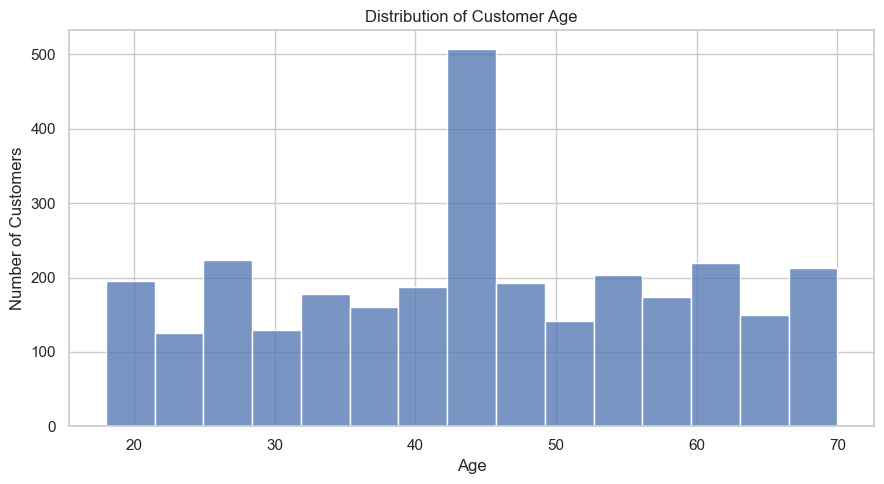

In [16]:

# age distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    data=customers,
    x="Age",
    bins=15
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

the histogram shows the distribution of customer ages across the finalized demographic dataset. the distribution is concentrated around the central age range, while fewer observations occur toward the extremes. this provides descriptive information that can guide later age-based feature engineering and scaling decisions, but the distribution alone does not establish that age predicts customer spending.

#### gender distribution

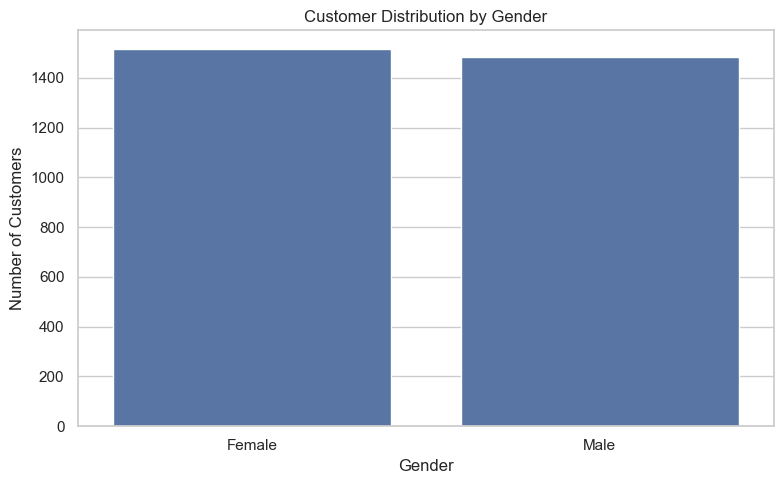

Gender
Female    50.5
Male      49.5
Name: proportion, dtype: float64

In [17]:
gender_counts = customers["Gender"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# calculate percentages
gender_percent = (
    customers["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(gender_percent)

#### income level

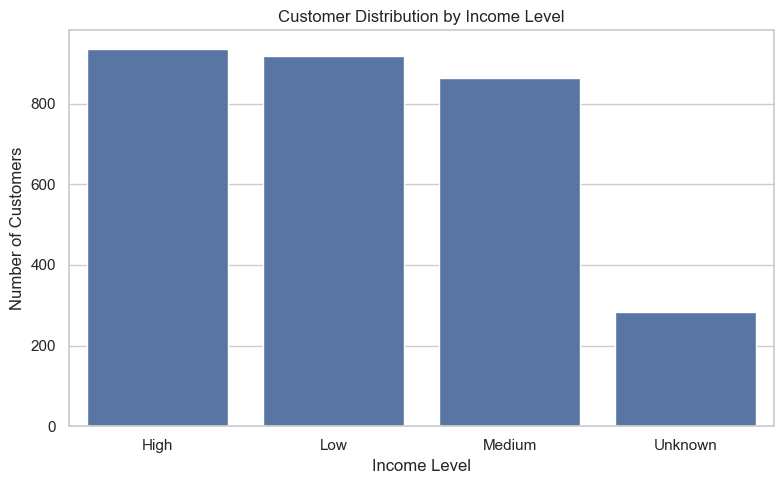

IncomeLevel
High       31.17
Low        30.60
Medium     28.77
Unknown     9.47
Name: proportion, dtype: float64

In [19]:
income_counts = customers["IncomeLevel"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=income_counts.index,
    y=income_counts.values
)

plt.title("Customer Distribution by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# calculate percentage
income_percent = (
    customers["IncomeLevel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(income_percent)

### customer transactions

#### transaction amount distribution

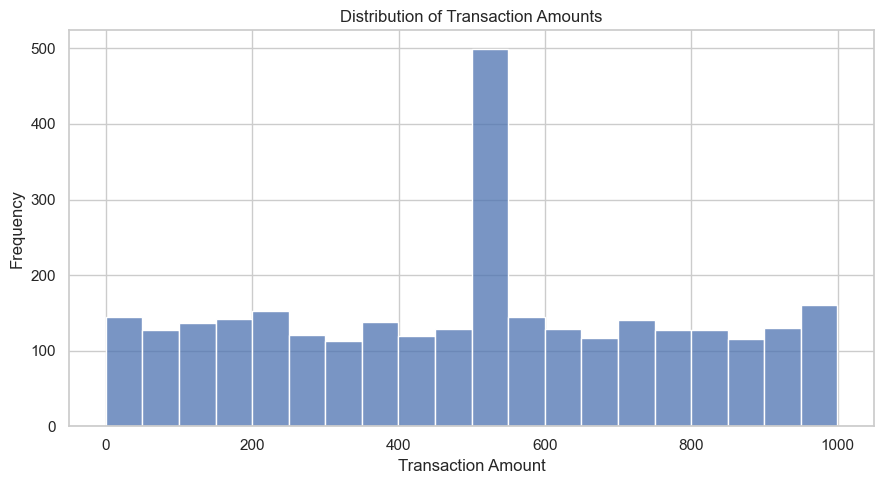

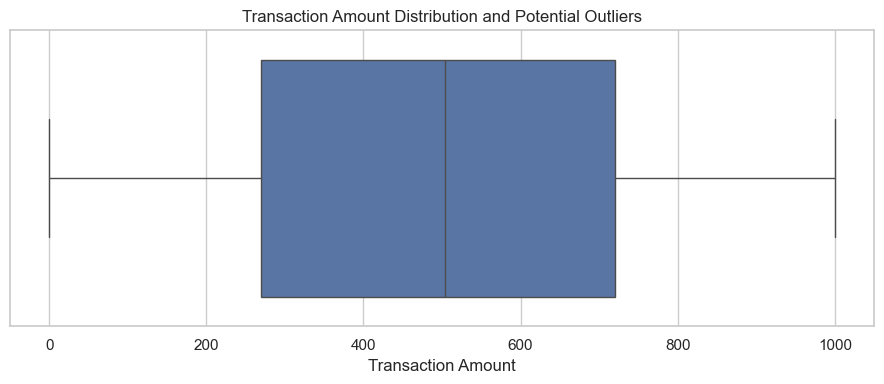

In [20]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=transactions,
    x="Amount",
    bins=20
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# boxplot
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=transactions,
    x="Amount"
)

plt.title("Transaction Amount Distribution and Potential Outliers")
plt.xlabel("Transaction Amount")
plt.tight_layout()
plt.show()

the box plot identifies observations that may be statistically unusual relative to the overall transaction distribution. these observations should be investigated according to their business meaning rather than automatically removed.

#### product categories

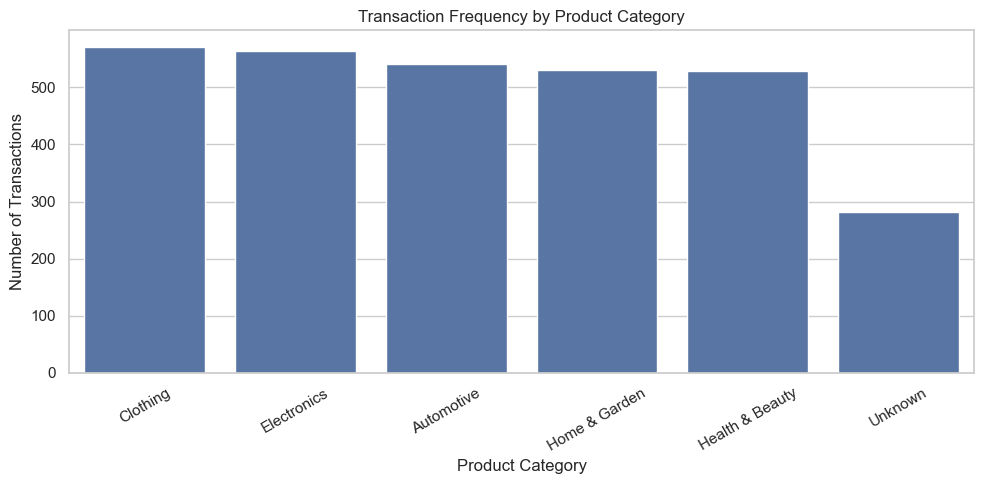

In [21]:
# transaction frequency
plt.figure(figsize=(10, 5))

sns.countplot(
    data=transactions,
    x="ProductCategory",
    order=transactions["ProductCategory"].value_counts().index
)

plt.title("Transaction Frequency by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



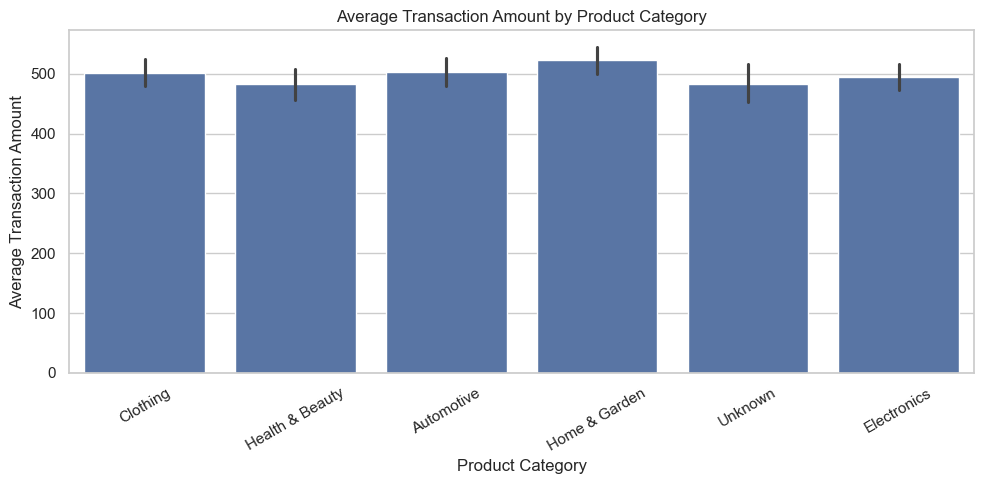

In [22]:
# average transaction amount
plt.figure(figsize=(10, 5))

sns.barplot(
    data=transactions,
    x="ProductCategory",
    y="Amount"
)

plt.title("Average Transaction Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### payment methods

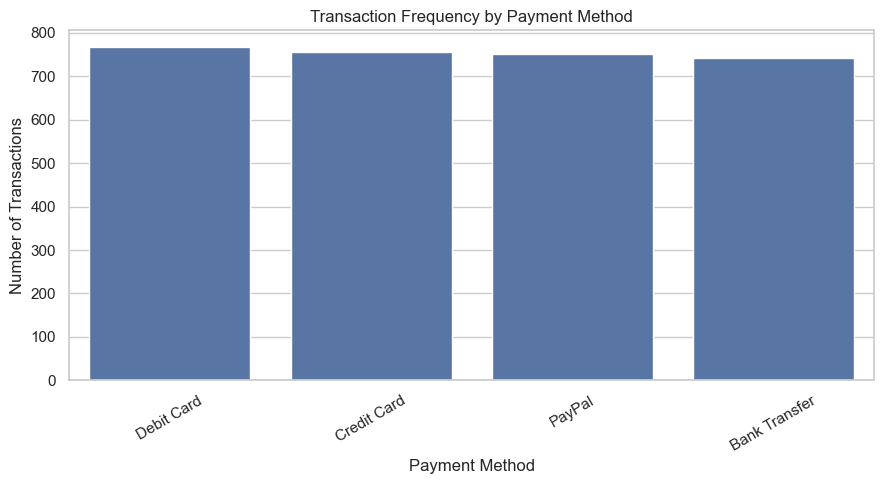

In [23]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=transactions,
    x="PaymentMethod",
    order=transactions["PaymentMethod"].value_counts().index
)

plt.title("Transaction Frequency by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### transaction trends

In [24]:
# convert to date first
transactions["TransactionDate"] = pd.to_datetime(
    transactions["TransactionDate"],
    errors="coerce"
)

In [25]:
monthly_transactions = (
    transactions
    .dropna(subset=["TransactionDate"])
    .set_index("TransactionDate")
    .resample("ME")
    .size()
)

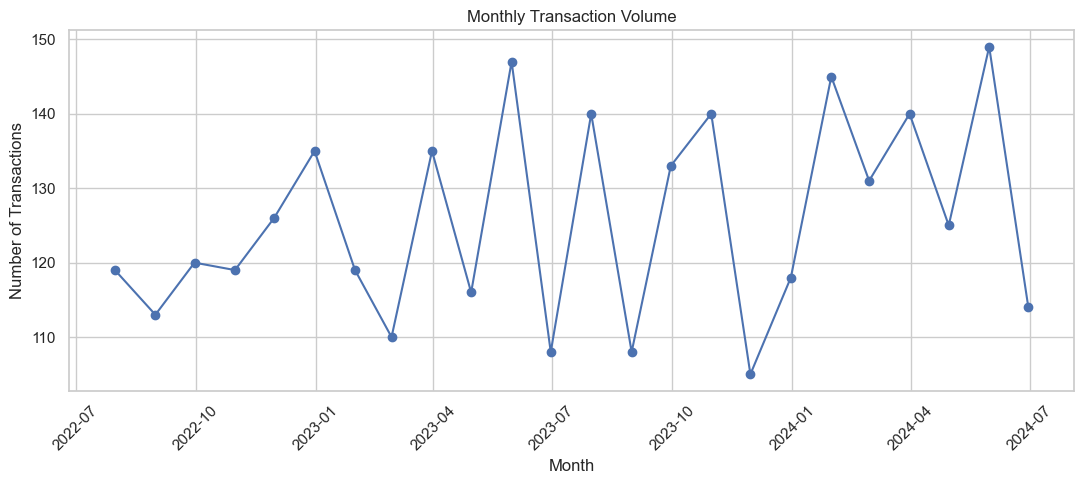

In [26]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_transactions.index,
    monthly_transactions.values,
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### social media interactions

In [28]:
# inspect column names first then use the actual categorical fields
print(social_media.columns.tolist())

['CustomerID', 'InteractionID', 'InteractionDate', 'Platform', 'InteractionType', 'Sentiment']


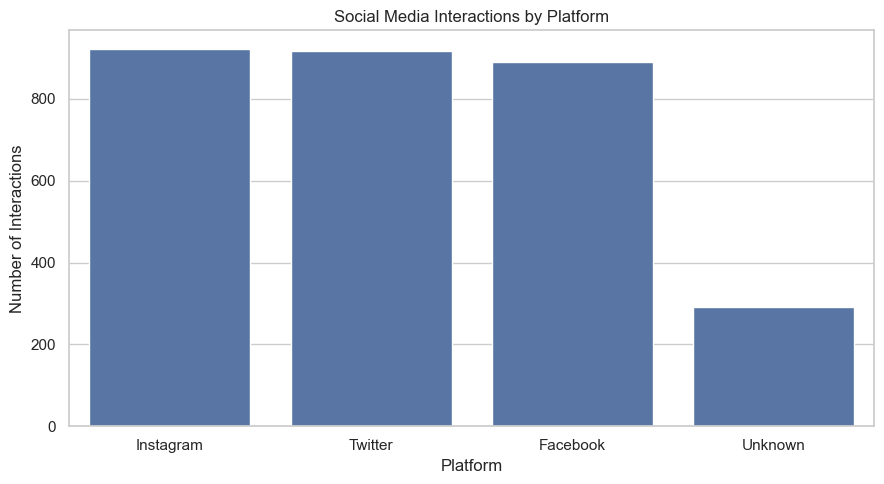

In [29]:
# platfirm
plt.figure(figsize=(9, 5))

sns.countplot(
    data=social_media,
    x="Platform",
    order=social_media["Platform"].value_counts().index
)

plt.title("Social Media Interactions by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

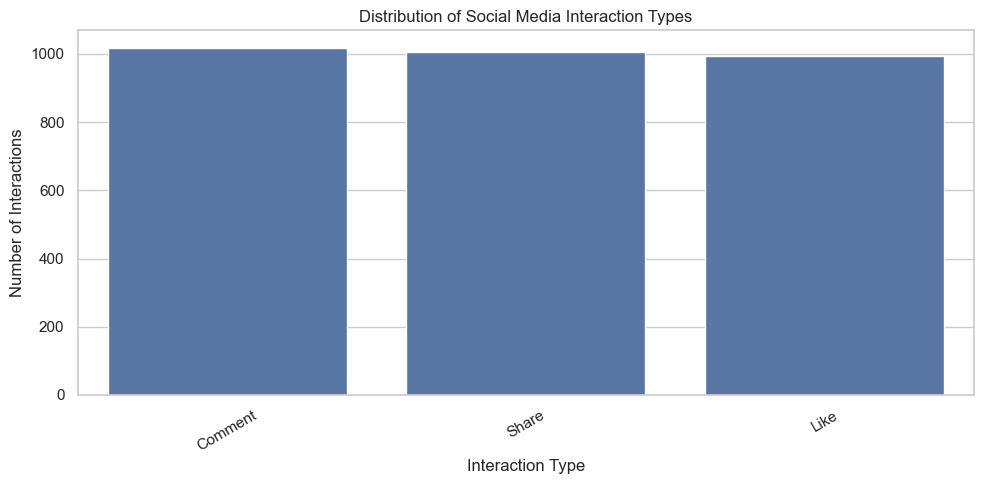

In [30]:
# interaction type
plt.figure(figsize=(10, 5))

sns.countplot(
    data=social_media,
    x="InteractionType",
    order=social_media["InteractionType"].value_counts().index
)

plt.title("Distribution of Social Media Interaction Types")
plt.xlabel("Interaction Type")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

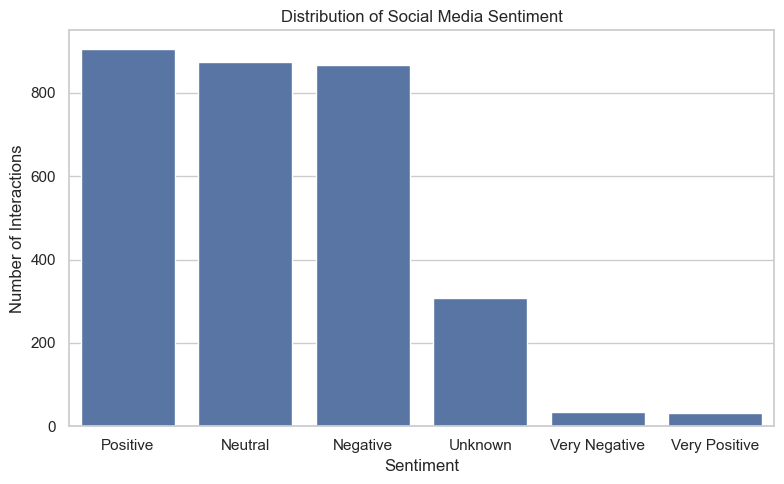

In [31]:
# sentiment
plt.figure(figsize=(8, 5))

sns.countplot(
    data=social_media,
    x="Sentiment",
    order=social_media["Sentiment"].value_counts().index
)

plt.title("Distribution of Social Media Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

the sentiment distribution is uneven, with some sentiment classes occurring less frequently than others. this imbalance may become relevant if sentiment is later used as a prediction target because minority classes may require appropriate evaluation metrics or resampling strategies.